# Bike Demand Classification with Logistic Regression

## 1. Imports and Data Loading

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [57]:
df = pd.read_csv("../data/hour.csv")
df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


## 2. Creating Demand Categories

In [58]:
def demand_category(count):
    if count < 150:
        return "low"
    elif count < 400:
        return "medium"
    else:
        return "high"

df["demand_category"] = df["cnt"].apply(demand_category)

df[["cnt", "demand_category"]].head(10)

,cnt,demand_category
0,16,low
1,40,low
2,32,low
3,13,low
4,1,low
5,1,low
6,2,low
7,3,low
8,8,low
9,14,low


In [59]:
demand_cat_dist = df["demand_category"].value_counts()
demand_cat_dist

demand_category
low       8965
medium    6124
high      2290
Name: count, dtype: int64

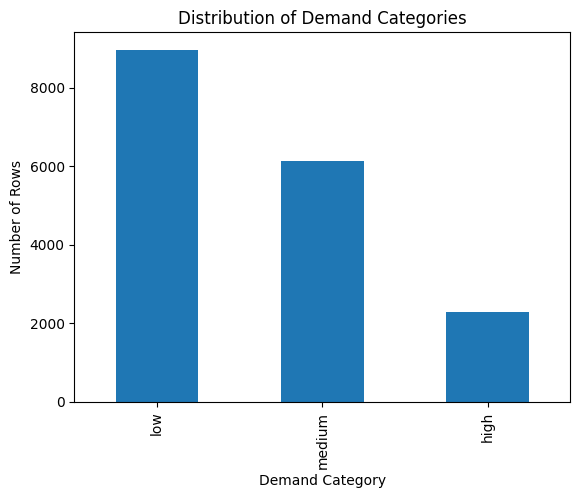

In [60]:
demand_cat_dist.plot(kind="bar")

plt.xlabel("Demand Category")
plt.ylabel("Number of Rows")
plt.title("Distribution of Demand Categories")
plt.show()

## 3. Feature Preparation

In [61]:
df["morning_commute"] = ((df["hr"].isin([7, 8])) & (df["workingday"] == 1)).astype(int)
df["evening_commute"] = ((df["hr"].isin([17, 18])) & (df["workingday"] == 1)).astype(int)
df["weekend"] = df["weekday"].isin([0, 6]).astype(int)

In [62]:
categorical_features = [
    "season",
    "mnth",
    "hr",
    "weekday",
    "weathersit"
]

numeric_features = [
    "yr",
    "holiday",
    "workingday",
    "temp",
    "hum",
    "windspeed",
    "morning_commute",
    "evening_commute",
    "weekend"
]

X = df[categorical_features + numeric_features]
y = df["demand_category"]

In [63]:
X_encoded = pd.get_dummies(
    X,
    columns=categorical_features,
    drop_first=True
)

X_encoded.head()

,yr,holiday,workingday,temp,hum,windspeed,morning_commute,evening_commute,weekend,season_2,...,hr_23,weekday_1,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6,weathersit_2,weathersit_3,weathersit_4
0,0,0,0,0.24,0.81,0.0,0,0,1,False,...,False,False,False,False,False,False,True,False,False,False
1,0,0,0,0.22,0.80,0.0,0,0,1,False,...,False,False,False,False,False,False,True,False,False,False
2,0,0,0,0.22,0.80,0.0,0,0,1,False,...,False,False,False,False,False,False,True,False,False,False
3,0,0,0,0.24,0.75,0.0,0,0,1,False,...,False,False,False,False,False,False,True,False,False,False
4,0,0,0,0.24,0.75,0.0,0,0,1,False,...,False,False,False,False,False,False,True,False,False,False


## Training and Testing Split

In [64]:
split_index = int(len(df) * 0.8)

X_train = X_encoded.iloc[:split_index]
X_test = X_encoded.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 13903
Testing rows: 3476


## Train Logistic Regression Model

In [65]:
logistic_model = LogisticRegression(max_iter=1000)

logistic_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

## Predictions and Model Evaluation

In [66]:
y_pred = logistic_model.predict(X_test)

y_pred[:10]

array(['medium', 'medium', 'medium', 'medium', 'medium', 'high', 'high',
       'high', 'medium', 'medium'], dtype=object)

In [67]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
0,medium,medium
1,medium,medium
2,medium,medium
3,medium,medium
4,high,medium
5,high,high
6,high,high
7,high,high
8,high,medium
9,medium,medium


In [68]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8253739930955121


In [69]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        high       0.84      0.74      0.78       767
         low       0.93      0.84      0.88      1411
      medium       0.73      0.86      0.79      1298

    accuracy                           0.83      3476
   macro avg       0.83      0.81      0.82      3476
weighted avg       0.84      0.83      0.83      3476



In [70]:
cm = confusion_matrix(y_test, y_pred, labels=["low", "medium", "high"])

cm_df = pd.DataFrame(
    cm,
    index=["Actual low", "Actual medium", "Actual high"],
    columns=["Predicted low", "Predicted medium", "Predicted high"]
)

cm_df

,Predicted low,Predicted medium,Predicted high
Actual low,1184,209,18
Actual medium,84,1121,93
Actual high,1,202,564


## Baseline Classifier

Before judging the logistic regression model, I compared it against a simple baseline classifier. This baseline always predicts the most common demand category from the training data.

If the logistic regression model only performs slightly better than this baseline, then it has not learned much. If it performs substantially better, then it is using the features to identify meaningful demand patterns.

In [71]:
most_common_class = y_train.value_counts().idxmax()

baseline_predictions = np.full(
    shape=len(y_test),
    fill_value=most_common_class
)

baseline_accuracy = accuracy_score(y_test, baseline_predictions)

print("Most common class:", most_common_class)
print("Baseline accuracy:", baseline_accuracy)
print("Logistic regression accuracy:", accuracy)

Most common class: low
Baseline accuracy: 0.4059263521288838
Logistic regression accuracy: 0.8253739930955121


## Baseline Classifier Results

The majority-class baseline always predicts the most common class in the training data, which is `low`. This baseline achieved an accuracy of about 40.6%.

The logistic regression model achieved an accuracy of about 82.5%, which is much higher than the baseline. This suggests that the model is learning meaningful patterns from the features rather than simply relying on the most common class.

## Classification Error Analysis

The logistic regression model performs much better than the majority-class baseline, but the confusion matrix shows that its main weakness is confusing some high-demand periods with medium-demand periods. I analyzed these errors to see when and where they occur.

In [72]:
classification_test_df = df.iloc[split_index:].copy()

classification_test_df["actual"] = y_test.values
classification_test_df["predicted"] = y_pred
classification_test_df["correct"] = classification_test_df["actual"] == classification_test_df["predicted"]

classification_test_df[["dteday", "hr", "weathersit", "temp", "hum", "actual", "predicted", "correct"]].head(10)

,dteday,hr,weathersit,temp,hum,actual,predicted,correct
13903,2012-08-07,12,2,0.80,0.55,medium,medium,True
13904,2012-08-07,13,2,0.80,0.52,medium,medium,True
13905,2012-08-07,14,2,0.82,0.46,medium,medium,True
13906,2012-08-07,15,1,0.80,0.52,medium,medium,True
13907,2012-08-07,16,3,0.76,0.66,high,medium,False
13908,2012-08-07,17,2,0.78,0.62,high,high,True
13909,2012-08-07,18,2,0.76,0.62,high,high,True
13910,2012-08-07,19,2,0.76,0.66,high,high,True
13911,2012-08-07,20,2,0.74,0.70,high,medium,False
13912,2012-08-07,21,2,0.72,0.74,medium,medium,True


In [73]:
incorrect_predictions = classification_test_df[classification_test_df["correct"] == False]

incorrect_predictions[["dteday", "hr", "weathersit", "temp", "hum", "actual", "predicted"]].head(10)

,dteday,hr,weathersit,temp,hum,actual,predicted
13907,2012-08-07,16,3,0.76,0.66,high,medium
13911,2012-08-07,20,2,0.74,0.70,high,medium
13921,2012-08-08,6,2,0.70,0.84,medium,low
13931,2012-08-08,16,2,0.80,0.49,high,medium
13935,2012-08-08,20,1,0.74,0.66,high,medium
13945,2012-08-09,6,1,0.66,0.83,medium,low
13946,2012-08-09,7,2,0.70,0.84,high,medium
13959,2012-08-09,20,1,0.70,0.54,high,medium
13962,2012-08-09,23,1,0.66,0.74,medium,low
13970,2012-08-10,7,3,0.64,0.89,low,medium


In [74]:
high_as_medium = classification_test_df[
    (classification_test_df["actual"] == "high") &
    (classification_test_df["predicted"] == "medium")
]

high_as_medium[["dteday", "hr", "weathersit", "temp", "hum", "actual", "predicted"]].head(10)

,dteday,hr,weathersit,temp,hum,actual,predicted
13907,2012-08-07,16,3,0.76,0.66,high,medium
13911,2012-08-07,20,2,0.74,0.70,high,medium
13931,2012-08-08,16,2,0.80,0.49,high,medium
13935,2012-08-08,20,1,0.74,0.66,high,medium
13946,2012-08-09,7,2,0.70,0.84,high,medium
13959,2012-08-09,20,1,0.70,0.54,high,medium
13979,2012-08-10,16,1,0.78,0.55,high,medium
13997,2012-08-11,10,1,0.72,0.62,high,medium
14004,2012-08-11,17,3,0.74,0.66,high,medium
14055,2012-08-13,20,1,0.74,0.62,high,medium


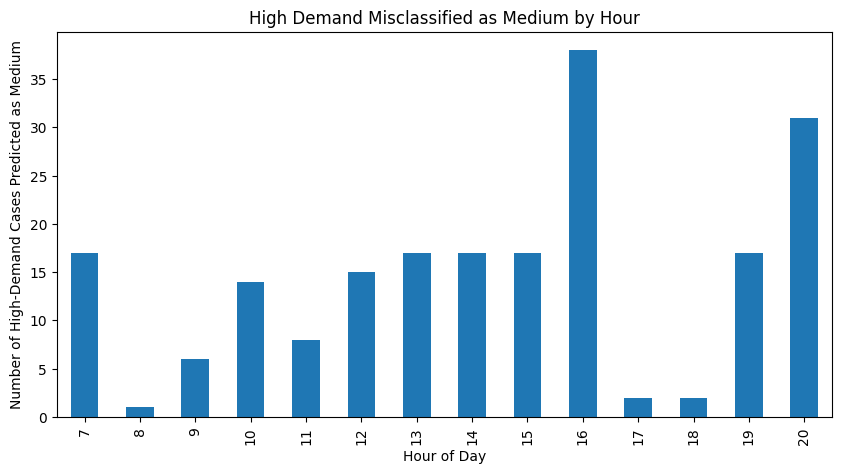

In [75]:
high_as_medium_by_hour = high_as_medium.groupby("hr").size()

plt.figure(figsize=(10, 5))
high_as_medium_by_hour.plot(kind="bar")

plt.xlabel("Hour of Day")
plt.ylabel("Number of High-Demand Cases Predicted as Medium")
plt.title("High Demand Misclassified as Medium by Hour")
plt.show()

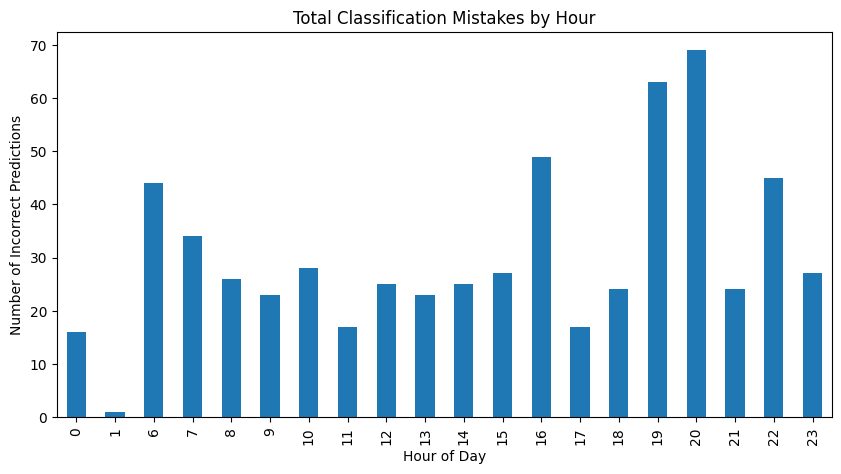

In [76]:
mistakes_by_hour = incorrect_predictions.groupby("hr").size()

plt.figure(figsize=(10, 5))
mistakes_by_hour.plot(kind="bar")

plt.xlabel("Hour of Day")
plt.ylabel("Number of Incorrect Predictions")
plt.title("Total Classification Mistakes by Hour")
plt.show()

## Classification Error Analysis Findings

The logistic regression model performs much better than the majority-class baseline, but the error analysis shows that its main weakness is underpredicting demand level.

The most common serious mistake is predicting `medium` when the actual class is `high`. This suggests that the model often recognizes that demand is not low, but it does not always classify high-demand periods aggressively enough.

The high-demand misclassifications are especially visible during afternoon and evening hours. This suggests that the model still struggles to fully separate upper-medium demand from truly high demand during busier parts of the day.

This may partly be caused by the threshold-based class definitions. Since `medium` and `high` are separated at 400 rentals, observations near that boundary may be difficult for the model to classify correctly. A demand value of 390 is labeled medium, while a value of 410 is labeled high, even though the two situations are practically very similar.

Overall, the model is useful, but its main limitation is that it sometimes underestimates high-demand periods as medium demand.

In [79]:
balanced_logistic_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

balanced_logistic_model.fit(X_train, y_train)

balanced_y_pred = balanced_logistic_model.predict(X_test)

In [80]:
balanced_accuracy = accuracy_score(y_test, balanced_y_pred)

print("Original logistic regression accuracy:", accuracy)
print("Balanced logistic regression accuracy:", balanced_accuracy)
print(classification_report(y_test, balanced_y_pred))

Original logistic regression accuracy: 0.8253739930955121
Balanced logistic regression accuracy: 0.7891254315304949
              precision    recall  f1-score   support

        high       0.66      0.89      0.76       767
         low       0.95      0.80      0.87      1411
      medium       0.74      0.72      0.73      1298

    accuracy                           0.79      3476
   macro avg       0.78      0.80      0.79      3476
weighted avg       0.81      0.79      0.79      3476



In [81]:
balanced_cm = confusion_matrix(
    y_test,
    balanced_y_pred,
    labels=["low", "medium", "high"]
)

balanced_cm_df = pd.DataFrame(
    balanced_cm,
    index=["Actual low", "Actual medium", "Actual high"],
    columns=["Predicted low", "Predicted medium", "Predicted high"]
)

balanced_cm_df

,Predicted low,Predicted medium,Predicted high
Actual low,1135,234,42
Actual medium,63,929,306
Actual high,1,87,679


## Balanced Logistic Regression Results

The balanced logistic regression model reduced the main weakness of the original logistic regression model. In the original model, many actual high-demand periods were predicted as medium demand. After using class weighting, the number of high-demand cases correctly classified as high increased substantially.

However, this came with a tradeoff. The balanced model had lower overall accuracy, decreasing from about 82.5% to 78.9%. This happened because the model became more aggressive about predicting high demand, which caused more medium-demand cases to be misclassified as high.

This shows an important classification tradeoff. The original model is better if the goal is maximum overall accuracy, while the balanced model is better if the goal is to avoid missing high-demand periods.

For a bike-sharing demand prediction system, the balanced model may be more useful operationally because failing to identify high-demand periods could lead to bike shortages.

In [82]:
classification_results = pd.DataFrame({
    "Model": [
        "Majority baseline",
        "Logistic regression",
        "Balanced logistic regression"
    ],
    "Accuracy": [
        baseline_accuracy,
        accuracy,
        balanced_accuracy
    ]
})

classification_results

,Model,Accuracy
0,Majority baseline,0.405926
1,Logistic regression,0.825374
2,Balanced logistic regression,0.789125
